In [1]:
#Data Loading & Initial Exploration for heart diseases

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("../data/subsets/brfss2024_subset.parquet")

sns.set_style("darkgrid")

print("Dataset Shape:", df.shape)
print("\nColumns:", list(df.columns[:10]))

print("\nRaw Heart Disease Values:")
print(df['has_heart_disease'].value_counts(dropna=False))

Dataset Shape: (457670, 78)

Columns: ['state_fips', 'primary_sampling_unit', 'sex_raw', 'general_health', 'days_poor_physical_health', 'days_poor_mental_health', 'days_poor_health_overall', 'insurance_type', 'has_personal_doctor', 'cant_afford_doctor']

Raw Heart Disease Values:
has_heart_disease
2.0    424581
1.0     28511
7.0      4297
9.0       278
NaN         3
Name: count, dtype: int64



Cleaned Distribution:
heart_disease_label
No Heart Disease    424581
Heart Disease        28511
Name: count, dtype: int64


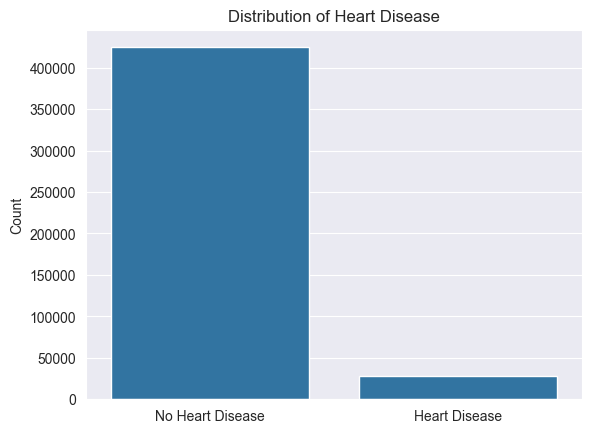

In [2]:
#Target Cleaning & Valid Response Filtering

# Keep only valid responses (1 = Yes, 2 = No)
df = df[df['has_heart_disease'].isin([1, 2])]

# Map labels
df['heart_disease_label'] = df['has_heart_disease'].map({
    1: 'Heart Disease',
    2: 'No Heart Disease'
})

# Check cleaned distribution
print("\nCleaned Distribution:")
print(df['heart_disease_label'].value_counts())
# CHUNK: Labeled Outcome Visualization

sns.countplot(x='heart_disease_label', data=df)
plt.title("Distribution of Heart Disease")
plt.xlabel("")
plt.ylabel("Count")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_36952\3449051108.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_hd.index.map(age_group_labels), y=age_hd.values, palette="viridis")


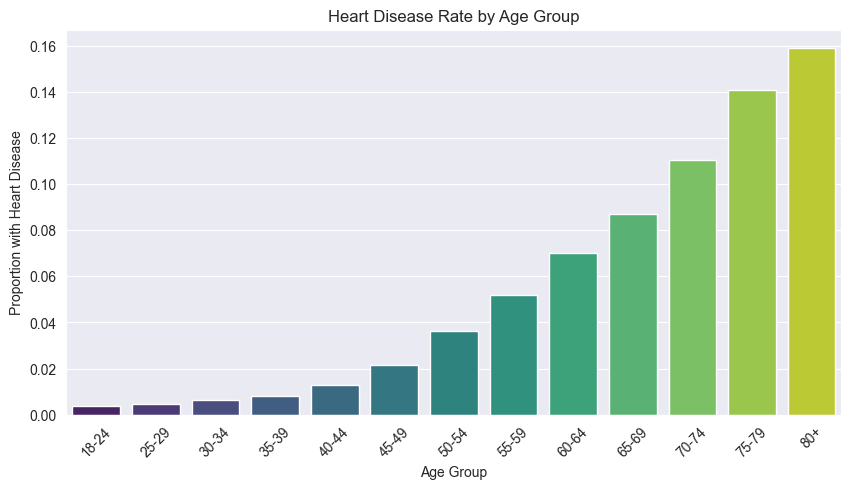

In [3]:
#Heart Disease Rate by Age Group (Labeled)

# Map 'has_heart_disease' to binary 0/1
df['hd_binary'] = df['has_heart_disease'].map({1:1, 2:0})

# Define age group labels
age_group_labels = {
    1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44',
    6: '45-49', 7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69',
    11: '70-74', 12: '75-79', 13: '80+'
}

# Calculate heart disease rate per age group
age_hd = df.groupby('age_group_5yr')['hd_binary'].mean().sort_index()

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=age_hd.index.map(age_group_labels), y=age_hd.values, palette="viridis")
plt.title("Heart Disease Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Proportion with Heart Disease")
plt.xticks(rotation=45)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_36952\2334225424.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sex_hd.index.map(sex_labels), y=sex_hd.values, palette="pastel")


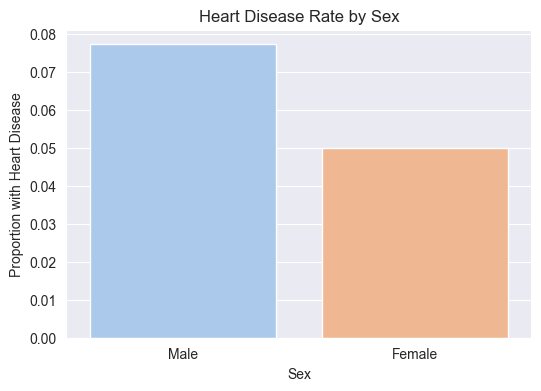

In [4]:
# Heart Disease by Sex

sex_labels = {1: 'Male', 2: 'Female'}

sex_hd = df.groupby('sex')['hd_binary'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=sex_hd.index.map(sex_labels), y=sex_hd.values, palette="pastel")
plt.title("Heart Disease Rate by Sex")
plt.ylabel("Proportion with Heart Disease")
plt.xlabel("Sex")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_36952\3383991782.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=race_hd.index.map(race_labels), y=race_hd.values, palette="coolwarm")


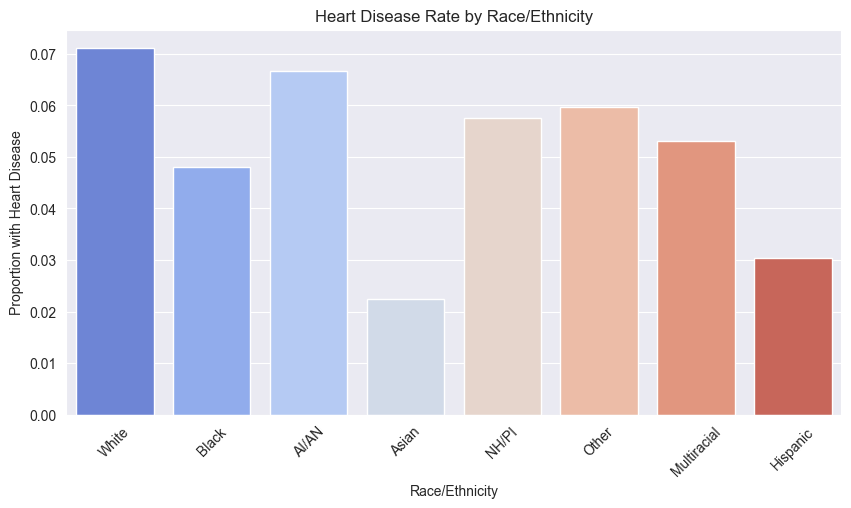

In [5]:
#Heart Disease by Race/Ethnicity

race_labels = {
    1: 'White', 2: 'Black', 3: 'AI/AN', 4: 'Asian', 5: 'NH/PI', 
    6: 'Other', 7: 'Multiracial', 8: 'Hispanic'
}

race_hd = df[df['race_ethnicity'].isin(race_labels.keys())].groupby('race_ethnicity')['hd_binary'].mean()

plt.figure(figsize=(10,5))
sns.barplot(x=race_hd.index.map(race_labels), y=race_hd.values, palette="coolwarm")
plt.title("Heart Disease Rate by Race/Ethnicity")
plt.ylabel("Proportion with Heart Disease")
plt.xlabel("Race/Ethnicity")
plt.xticks(rotation=45)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_36952\3438749365.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_hd.index.map(education_labels), y=edu_hd.values, palette="Set2")


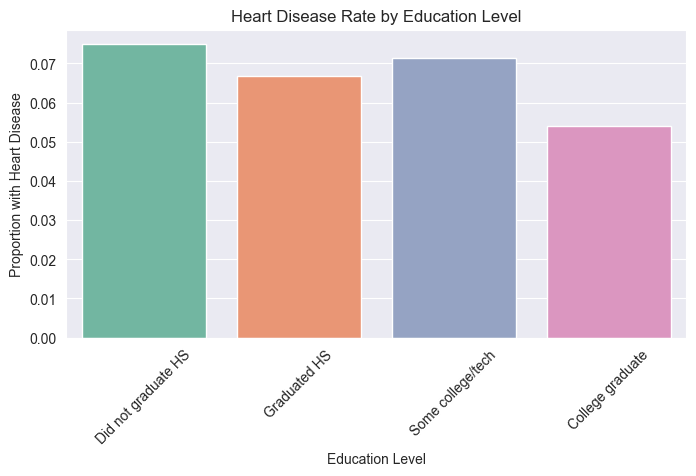

In [6]:
#Heart Disease by Education Level

education_labels = {
    1: 'Did not graduate HS', 2: 'Graduated HS', 3: 'Some college/tech', 4: 'College graduate'
}

edu_hd = df[df['education_level'].isin(education_labels.keys())].groupby('education_level')['hd_binary'].mean()

plt.figure(figsize=(8,4))
sns.barplot(x=edu_hd.index.map(education_labels), y=edu_hd.values, palette="Set2")
plt.title("Heart Disease Rate by Education Level")
plt.ylabel("Proportion with Heart Disease")
plt.xlabel("Education Level")
plt.xticks(rotation=45)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_36952\766900512.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bmi_hd.index.map(bmi_labels), y=bmi_hd.values, palette="magma")


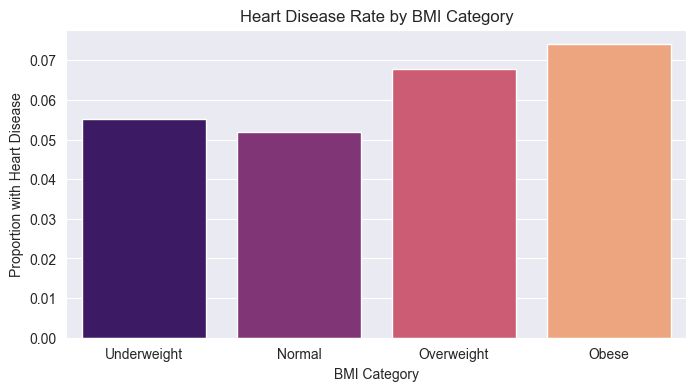

In [7]:
#: Heart Disease by BMI Category

bmi_labels = {1:'Underweight', 2:'Normal', 3:'Overweight', 4:'Obese'}

bmi_hd = df[df['bmi_category'].isin(bmi_labels.keys())].groupby('bmi_category')['hd_binary'].mean()

plt.figure(figsize=(8,4))
sns.barplot(x=bmi_hd.index.map(bmi_labels), y=bmi_hd.values, palette="magma")
plt.title("Heart Disease Rate by BMI Category")
plt.ylabel("Proportion with Heart Disease")
plt.xlabel("BMI Category")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_36952\1646223896.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=smoke_hd.index.map(smoking_labels), y=smoke_hd.values, palette="cividis")


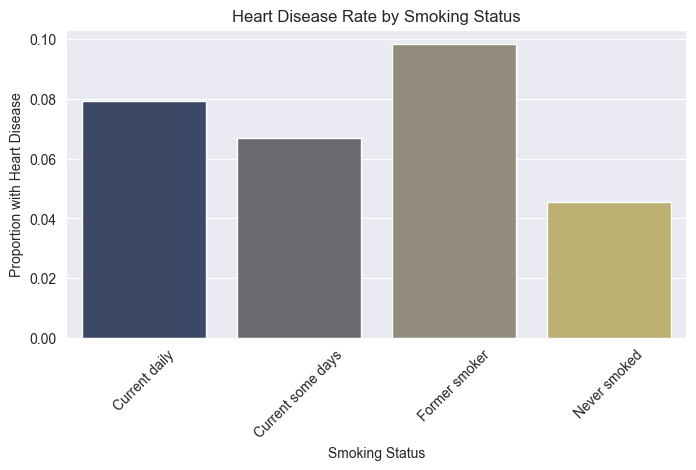

In [8]:
#Heart Disease by Smoking Status

smoking_labels = {1:'Current daily', 2:'Current some days', 3:'Former smoker', 4:'Never smoked'}

smoke_hd = df[df['smoking_status'].isin(smoking_labels.keys())].groupby('smoking_status')['hd_binary'].mean()

plt.figure(figsize=(8,4))
sns.barplot(x=smoke_hd.index.map(smoking_labels), y=smoke_hd.values, palette="cividis")
plt.title("Heart Disease Rate by Smoking Status")
plt.ylabel("Proportion with Heart Disease")
plt.xlabel("Smoking Status")
plt.xticks(rotation=45)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_36952\2116755783.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=diabetes_hd.index.map(diabetes_labels), y=diabetes_hd.values, palette="rocket")


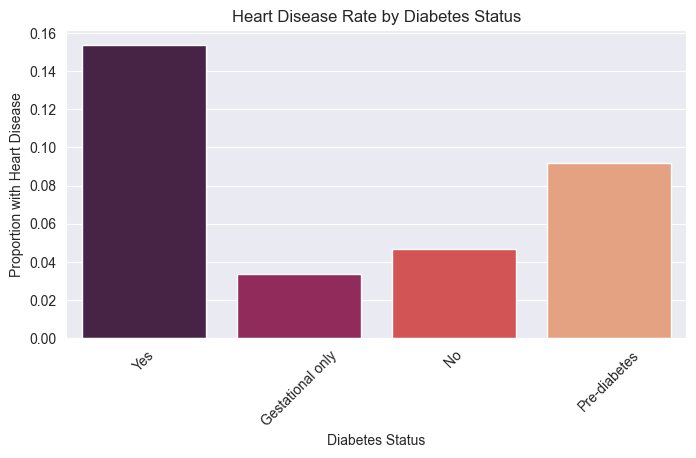

In [9]:
#Heart Disease by Diabetes Status

diabetes_labels = {1:'Yes', 2:'Gestational only', 3:'No', 4:'Pre-diabetes'}

diabetes_hd = df[df['has_diabetes'].isin(diabetes_labels.keys())].groupby('has_diabetes')['hd_binary'].mean()

plt.figure(figsize=(8,4))
sns.barplot(x=diabetes_hd.index.map(diabetes_labels), y=diabetes_hd.values, palette="rocket")
plt.title("Heart Disease Rate by Diabetes Status")
plt.ylabel("Proportion with Heart Disease")
plt.xlabel("Diabetes Status")
plt.xticks(rotation=45)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_36952\3066204409.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exercise_hd.index.map(exercise_labels), y=exercise_hd.values, palette="Greens")


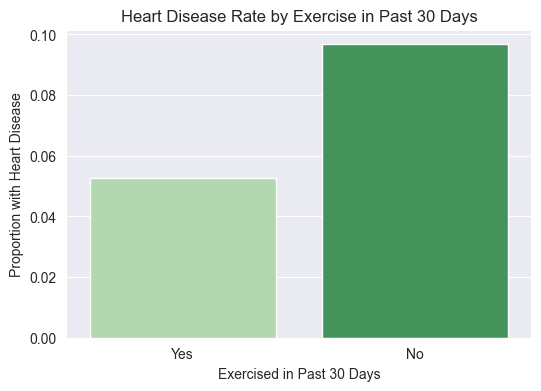

In [10]:
#Heart Disease by Exercise in Past 30 Days

exercise_labels = {1: 'Yes', 2: 'No'}

exercise_hd = df[df['exercised_past_30d'].isin(exercise_labels.keys())].groupby('exercised_past_30d')['hd_binary'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=exercise_hd.index.map(exercise_labels), y=exercise_hd.values, palette="Greens")
plt.title("Heart Disease Rate by Exercise in Past 30 Days")
plt.ylabel("Proportion with Heart Disease")
plt.xlabel("Exercised in Past 30 Days")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_36952\4138422041.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=alcohol_hd.index.map(alcohol_labels), y=alcohol_hd.values, palette="Blues")


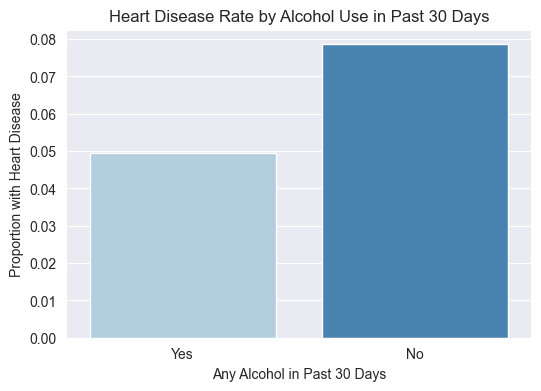

In [11]:
#Heart Disease by Alcohol Use

alcohol_labels = {1: 'Yes', 2: 'No'}

alcohol_hd = df[df['any_alcohol_past_30d'].isin(alcohol_labels.keys())].groupby('any_alcohol_past_30d')['hd_binary'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=alcohol_hd.index.map(alcohol_labels), y=alcohol_hd.values, palette="Blues")
plt.title("Heart Disease Rate by Alcohol Use in Past 30 Days")
plt.ylabel("Proportion with Heart Disease")
plt.xlabel("Any Alcohol in Past 30 Days")
plt.show()

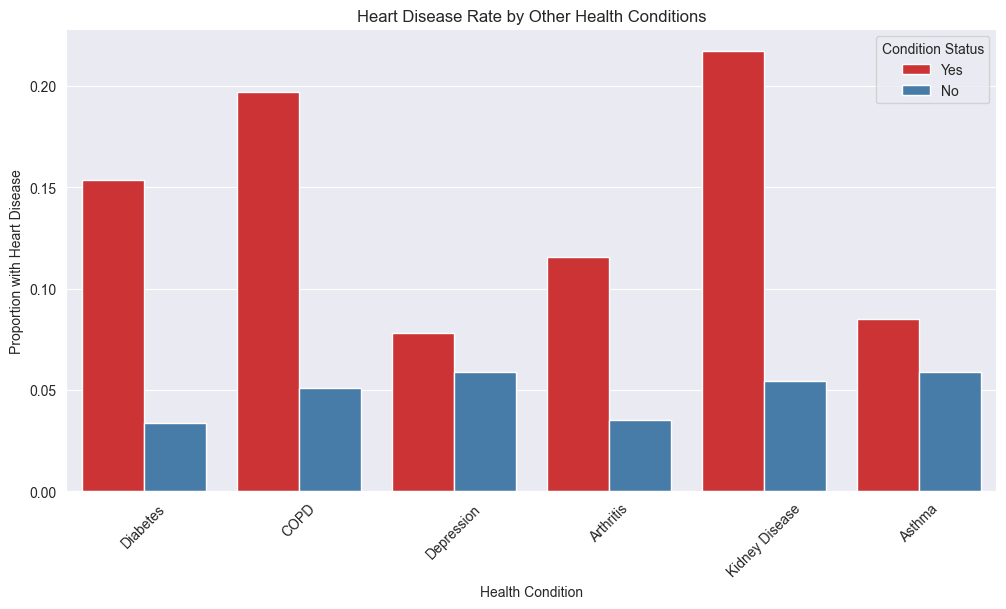

In [12]:
# Define health condition columns and readable labels
health_conditions = {
    'has_diabetes': 'Diabetes',
    'has_copd': 'COPD',
    'has_depression': 'Depression',
    'has_arthritis': 'Arthritis',
    'has_kidney_disease': 'Kidney Disease',
    'had_asthma': 'Asthma'
}

hd_summary = []

for col, readable_name in health_conditions.items():
    if col not in df.columns:
        continue  # skip if column missing
    # Keep only valid responses (1 = Yes, 2 = No)
    valid_df = df[df[col].isin([1,2])]
    temp = valid_df.groupby(col)['hd_binary'].mean().reset_index()
    temp['Condition'] = readable_name
    temp['Label'] = temp[col].map({1:'Yes', 2:'No'})
    hd_summary.append(temp[['Condition','Label','hd_binary']])

# Combine all conditions
hd_summary_df = pd.concat(hd_summary, ignore_index=True)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='Condition', y='hd_binary', hue='Label', data=hd_summary_df, palette="Set1")
plt.title("Heart Disease Rate by Other Health Conditions")
plt.ylabel("Proportion with Heart Disease")
plt.xlabel("Health Condition")
plt.legend(title="Condition Status")
plt.xticks(rotation=45)
plt.show()

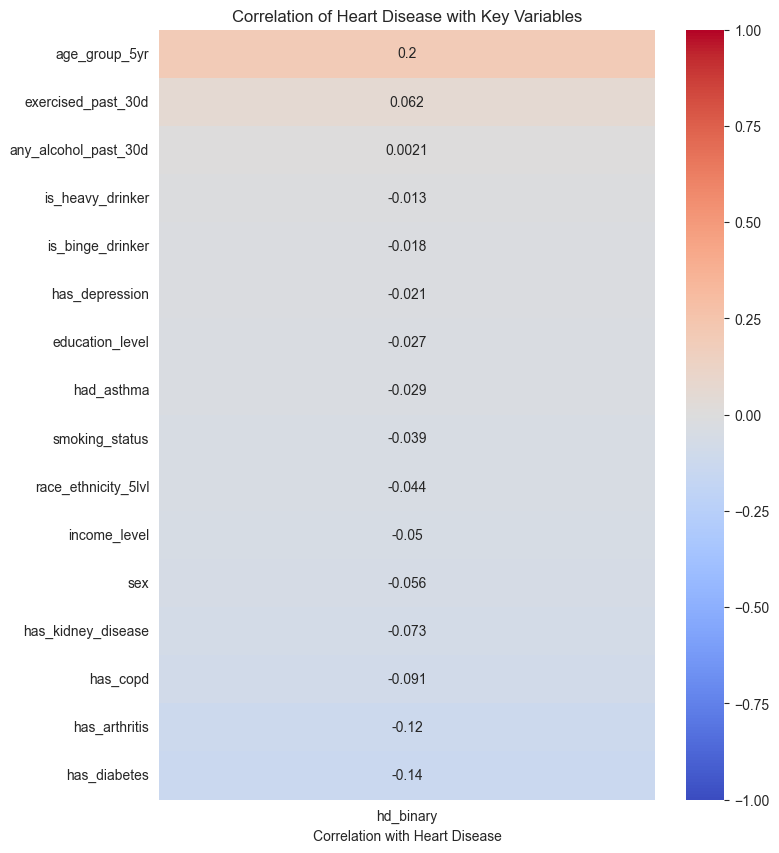

In [13]:
# List of variables to include
variables = [
    'sex', 'age_group_5yr', 'race_ethnicity_5lvl', 'education_level', 'income_level',
    'smoking_status', 'any_alcohol_past_30d', 'is_binge_drinker', 'is_heavy_drinker', 'exercised_past_30d',
    'has_diabetes', 'had_asthma', 'has_copd', 'has_depression', 'has_arthritis', 'has_kidney_disease'
]

# Keep only variables that exist in df
variables = [v for v in variables if v in df.columns]

# Compute correlation with heart disease
corr_matrix = df[variables + ['hd_binary']].corr()

# Extract correlation with heart disease only
hd_corr = corr_matrix[['hd_binary']].drop('hd_binary').sort_values('hd_binary', ascending=False)

# Plot
plt.figure(figsize=(8,10))
sns.heatmap(hd_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation of Heart Disease with Key Variables")
plt.xlabel("Correlation with Heart Disease")
plt.show()